# Phân tích Mô tả (Descriptive Analysis)
## Dataset: Power Consumption of Tetouan City

Notebook này thực hiện phân tích mô tả chi tiết cho bộ dữ liệu tiêu thụ điện năng thành phố Tetouan (Morocco), bao gồm:
1. Đọc & kiểm tra tổng quan dữ liệu
2. Làm sạch & chuẩn hóa dữ liệu
3. Thống kê mô tả
4. Trực quan hóa phân phối
5. Phân tích chuỗi thời gian (theo giờ, tháng, ngày trong tuần)
6. Phân tích tương quan
7. So sánh giữa 3 khu vực
8. Tổng hợp kết luận


## 1. Chuẩn bị môi trường

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")


## 2. Đọc và kiểm tra tổng quan dữ liệu


In [2]:
file_path = "Tetuan City power consumption.csv"

df = pd.read_csv(file_path)
df.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [3]:
df.shape

(52416, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   DateTime                   52416 non-null  str    
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   Wind Speed                 52416 non-null  float64
 4   general diffuse flows      52416 non-null  float64
 5   diffuse flows              52416 non-null  float64
 6   Zone 1 Power Consumption   52416 non-null  float64
 7   Zone 2  Power Consumption  52416 non-null  float64
 8   Zone 3  Power Consumption  52416 non-null  float64
dtypes: float64(8), str(1)
memory usage: 3.6 MB


In [5]:
df.columns.tolist()

['DateTime',
 'Temperature',
 'Humidity',
 'Wind Speed',
 'general diffuse flows',
 'diffuse flows',
 'Zone 1 Power Consumption',
 'Zone 2  Power Consumption',
 'Zone 3  Power Consumption']

**Kết luận:** Dataset gồm **52.416 dòng x 9 cột**, tần suất ghi nhận **10 phút/lần** xuyên suốt năm 2017, đầy đủ 8 biến số (khí hậu + tiêu thụ điện 3 khu vực) và 1 biến thời gian. 

## 3. Làm sạch & chuẩn hóa dữ liệu

### 3.1. Chuyển đổi kiểu dữ liệu thời gian

In [6]:
df["DateTime"] = pd.to_datetime(df["DateTime"])
df = df.sort_values("DateTime").reset_index(drop=True)
df.set_index("DateTime", inplace=True)
df.head()


,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Zone 1 Power Consumption,Zone 2 Power Consumption,Zone 3 Power Consumption
DateTime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


### 3.2. Đặt lại tên cột

In [7]:
df.columns = ["Temperature", "Humidity", "WindSpeed",
              "GeneralDiffuseFlows", "DiffuseFlows",
              "Zone1_PowerConsumption", "Zone2_PowerConsumption",
              "Zone3_PowerConsumption"]
df.head()


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,Zone1_PowerConsumption,Zone2_PowerConsumption,Zone3_PowerConsumption
DateTime,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


### 3.3. Kiểm tra giá trị thiếu (missing values)

In [8]:
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
Temperature,0,0.0
Humidity,0,0.0
WindSpeed,0,0.0
GeneralDiffuseFlows,0,0.0
DiffuseFlows,0,0.0
Zone1_PowerConsumption,0,0.0
Zone2_PowerConsumption,0,0.0
Zone3_PowerConsumption,0,0.0


In [9]:
if df.isnull().sum().sum() > 0:
    df = df.interpolate(method="time")
    print("Đã nội suy giá trị thiếu.")
else:
    print("Không có giá trị thiếu.")


Không có giá trị thiếu.


### 3.4. Kiểm tra trùng lặp

In [10]:
print("Số dòng trùng lặp:", df.duplicated().sum())
print("Số timestamp trùng lặp:", df.index.duplicated().sum())


Số dòng trùng lặp: 0
Số timestamp trùng lặp: 0


### 3.5. Kiểm tra giá trị bất thường sơ bộ

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,52416.0,18.810024,5.815476,3.247000,14.410000,18.780000,22.890000,40.01000
Humidity,52416.0,68.259518,15.551177,11.340000,58.310000,69.860000,81.400000,94.80000
WindSpeed,52416.0,1.959489,2.348862,0.050000,0.078000,0.086000,4.915000,6.48300
GeneralDiffuseFlows,52416.0,182.696614,264.400960,0.004000,0.062000,5.035500,319.600000,1163.00000
DiffuseFlows,52416.0,75.028022,124.210949,0.011000,0.122000,4.456000,101.000000,936.00000
Zone1_PowerConsumption,52416.0,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512
Zone2_PowerConsumption,52416.0,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076
Zone3_PowerConsumption,52416.0,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636


In [12]:
# Kiểm tra các giá trị ngoài khoảng hợp lý
print("Nhiệt độ âm bất thường:", (df["Temperature"] < -10).sum())
print("Độ ẩm ngoài [0,100]:", ((df["Humidity"] < 0) | (df["Humidity"] > 100)).sum())
for zone in ["Zone1_PowerConsumption", "Zone2_PowerConsumption", "Zone3_PowerConsumption"]:
    print(f"{zone} âm:", (df[zone] < 0).sum())


Nhiệt độ âm bất thường: 0
Độ ẩm ngoài [0,100]: 0
Zone1_PowerConsumption âm: 0
Zone2_PowerConsumption âm: 0
Zone3_PowerConsumption âm: 0


**Kết luận:** Dữ liệu **sạch** — không có giá trị thiếu, không có dòng trùng lặp, không có giá trị âm hay ngoài khoảng hợp lý (nhiệt độ, độ ẩm, tiêu thụ điện đều nằm trong phạm vi vật lý bình thường). Không cần xử lý thêm về chất lượng dữ liệu.

## 4. Thống kê mô tả (Descriptive Statistics)

### 4.1. Thống kê tổng quát

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,52416.0,18.810024,5.815476,3.247000,14.410000,18.780000,22.890000,40.01000
Humidity,52416.0,68.259518,15.551177,11.340000,58.310000,69.860000,81.400000,94.80000
WindSpeed,52416.0,1.959489,2.348862,0.050000,0.078000,0.086000,4.915000,6.48300
GeneralDiffuseFlows,52416.0,182.696614,264.400960,0.004000,0.062000,5.035500,319.600000,1163.00000
DiffuseFlows,52416.0,75.028022,124.210949,0.011000,0.122000,4.456000,101.000000,936.00000
Zone1_PowerConsumption,52416.0,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512
Zone2_PowerConsumption,52416.0,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076
Zone3_PowerConsumption,52416.0,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636


**Kết luận:**
- **Zone 1** tiêu thụ điện cao nhất và ổn định nhất (mean ≈ 32.345 KW, std ≈ 7.131).
- **Zone 3** có độ lệch chuẩn tương đối lớn nhất so với mean (biến động mạnh nhất trong 3 khu vực).
- **GeneralDiffuseFlows** và **DiffuseFlows** có độ lệch chuẩn rất lớn so với mean, median gần 0 trong khi max lên tới hàng trăm/nghìn → phân phối lệch mạnh, phần lớn giá trị tập trung gần 0 (ban đêm không có bức xạ).

### 4.2. Độ lệch (skewness) và độ nhọn (kurtosis)

In [14]:
stats_df = pd.DataFrame({
    "skewness": df.skew(numeric_only=True),
    "kurtosis": df.kurtosis(numeric_only=True)
})
stats_df


,skewness,kurtosis
Temperature,0.196719,-0.303321
Humidity,-0.625166,-0.121860
WindSpeed,0.462423,-1.783169
GeneralDiffuseFlows,1.306973,0.402768
DiffuseFlows,2.456907,7.002902
Zone1_PowerConsumption,0.228864,-0.754054
Zone2_PowerConsumption,0.328876,-0.437397
Zone3_PowerConsumption,1.023871,1.086393


**Kết luận:**
- **DiffuseFlows** lệch phải cực mạnh (skew 2.46, kurtosis 7.0) — phần lớn thời gian giá trị gần 0, chỉ tăng vọt vào thời điểm nắng gắt giữa trưa.
- **Zone3_PowerConsumption** lệch phải rõ rệt (skew 1.02) — có các đợt tăng đột biến (trùng với mùa hè).
- **Humidity** hơi lệch trái (-0.63) — độ ẩm thường duy trì ở mức cao (median ~70%).
- **Zone1, Zone2** có skew thấp, phân phối tương đối cân đối.

### 4.3. Tạo các biến thời gian phụ trợ

In [15]:
df["hour"] = df.index.hour
df["month"] = df.index.month
df["dayofweek"] = df.index.dayofweek  # 0 = Thứ 2
df["is_weekend"] = df["dayofweek"].isin([5, 6])
df["season"] = df["month"] % 12 // 3 + 1  # 1: Đông, 2: Xuân, 3: Hè, 4: Thu
df.head()


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,Zone1_PowerConsumption,Zone2_PowerConsumption,Zone3_PowerConsumption,hour,month,dayofweek,is_weekend,season
DateTime,,,,,,,,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386,0,1,6,True,1
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434,0,1,6,True,1
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373,0,1,6,True,1
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711,0,1,6,True,1
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964,0,1,6,True,1


### 4.4. Thống kê theo giờ và theo tháng

In [16]:
hourly_stats = df.groupby("hour")[["Zone1_PowerConsumption",
                                        "Zone2_PowerConsumption",
                                        "Zone3_PowerConsumption"]].mean()
hourly_stats


,Zone1_PowerConsumption,Zone2_PowerConsumption,Zone3_PowerConsumption
hour,,,
0,30217.235372,19692.073550,18657.222811
1,27565.533030,17765.078949,16970.804696
2,26292.688917,16730.156092,15981.096176
3,25338.122851,16052.585288,15238.605002
4,24633.576717,15624.081077,14671.039080
5,23437.577276,14974.907723,13226.380008
6,23203.597394,14934.698604,12051.599729
7,24038.353352,15719.115067,11667.864458
8,26583.262396,17529.678454,12793.786057


**Kết luận:** Cả 3 khu vực đều có mẫu hình **2 đỉnh tiêu thụ rõ rệt theo giờ**: thấp điểm vào **5-6h sáng**, tăng dần buổi sáng, chững nhẹ buổi trưa, rồi đạt **đỉnh cao nhất lúc 19-20h tối** (Zone 1 ~43.800 KW, Zone 3 tăng gấp ~2,2 lần so với đáy). Đây là mẫu hình sinh hoạt điển hình: nhu cầu điện tăng mạnh vào giờ tan tầm/tối do chiếu sáng và sinh hoạt gia đình.

In [17]:
monthly_stats = df.groupby("month")[["Zone1_PowerConsumption",
                                          "Zone2_PowerConsumption",
                                          "Zone3_PowerConsumption"]].agg(["mean", "min", "max", "std"])
monthly_stats


Zone1_PowerConsumption                                         \
                        mean          min          max          std   
month                                                                 
1               31032.493535  13895.69620  46092.15190  7400.277974   
2               30985.753632  18128.13559  44975.59322  6869.042633   
3               31155.165408  18003.06383  47808.00000  6777.753954   
4               31169.768210  16814.98385  46824.02583  6485.660448   
5               32396.009166  17689.18033  48157.37705  6801.738885   
6               34605.540839  19467.01987  49360.52980  7317.124026   
7               35831.553603  20303.52159  51540.19934  6977.984271   
8               36435.189574  18283.68479  52204.39512  7061.593959   
9               33396.681416  20172.74336  48380.17699  6502.955490   
10              32827.660055  19605.42670  47661.79431  6491.561870   
11              29002.106838  17483.07692  42566.15385  5902.676988   
12              29024.168427  17624.33460  43972.62357  6176.400951   

      Zone2_PowerConsumption                                          \
                        mean           min          max          std   
month                                                                  
1               19394.444717   9457.750760  29770.21277  4522.184101   
2               18787.793096   9997.568389  29719.14894  4391.322168   
3               18457.937484   9695.121951  29056.09756  4181.243776   
4               17633.966395   8560.081466  30940.93686  3833.902391   
5               19977.287859   9365.944272  29502.16718  4179.123200   
6               20670.928621   9972.972973  30109.77131  4457.492438   
7               24147.886893  12497.468350  37408.86076  4966.458343   
8               24656.216575  11674.340020  36482.78775  5157.584966   
9               20180.432259  10624.116420  32545.94595  4221.332584   
10              21468.993441  11158.506220  34860.99585  4615.926881   
11              23240.464015  12138.842980  35631.81818  5432.053890   
12              23681.852818  12368.211110  35138.38601  5711.791190   

      Zone3_PowerConsumption                                          
                        mean           min          max          std  
month                                                                 
1               17746.095349  10039.518070  27724.33735  4433.847680  
2               17335.002154   9592.281407  28145.84925  4359.983745  
3               16947.686004   9348.387097  27720.00000  4251.364622  
4               18593.167677  10065.454550  29666.90909  4544.808792  
5               17621.100953   9840.971660  28030.44534  4357.844657  
6               20430.941538  10379.815380  33756.55385  5606.910346  
7               28194.111216  13562.510460  47598.32636  6933.659265  
8               24648.894732   9961.128527  41415.42320  6499.414490  
9               14922.798774   6707.252298  25575.81205  3438.638229  
10              13264.095173   7446.565350  20734.83283  3092.951087  
11              12862.496653   6511.807229  25972.04819  3510.025228  
12              11044.805922   5935.174070  17505.88235  2853.391812

**Kết luận:**
- **Zone 1 & Zone 2** đạt đỉnh tiêu thụ vào **tháng 7-8** (mùa hè, nhu cầu làm mát cao), thấp nhất vào tháng 11-12.
- **Zone 3** biến động mùa vụ mạnh nhất: tăng đột biến tháng 7 (mean ≈ 28.194 KW so với ~17.000 các tháng khác) rồi giảm sâu về cuối năm (tháng 12 chỉ ≈ 11.045 KW) → khu vực này **nhạy cảm nhất với yếu tố mùa vụ/nhiệt độ**.

## 5. Trực quan hóa phân phối từng biến

### 5.1. Histogram + KDE

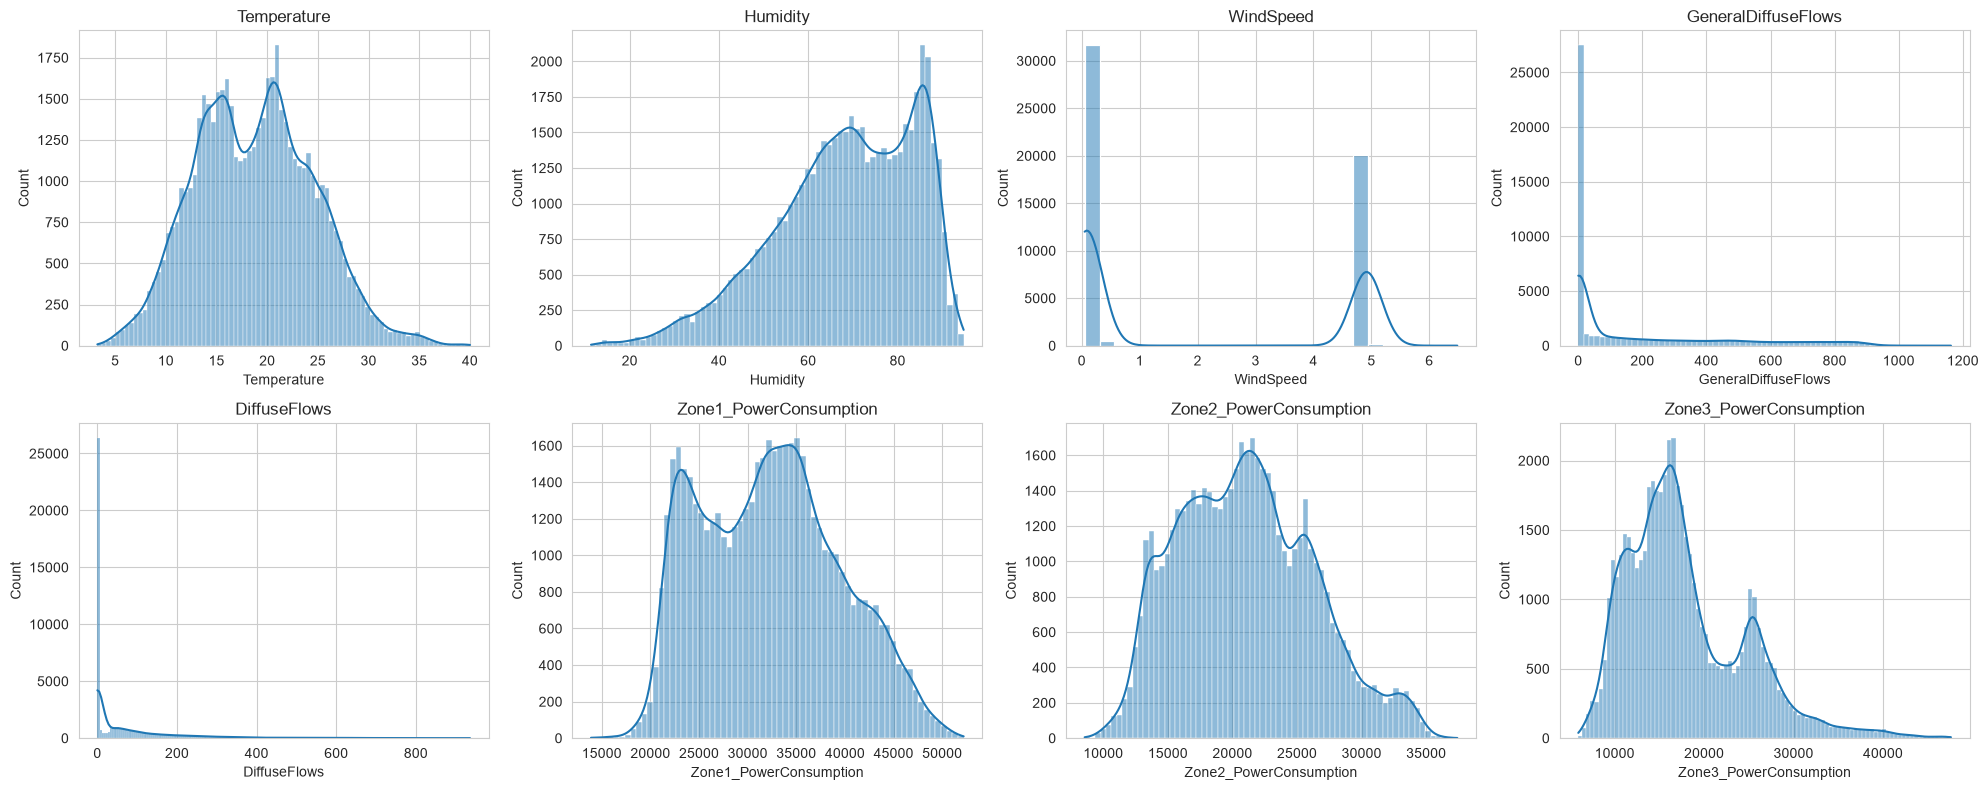

In [18]:
num_cols = ["Temperature", "Humidity", "WindSpeed",
            "GeneralDiffuseFlows", "DiffuseFlows",
            "Zone1_PowerConsumption", "Zone2_PowerConsumption",
            "Zone3_PowerConsumption"]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Kết luận:**
- **Temperature, Zone1, Zone2** có phân phối 2 đỉnh (bimodal) — phản ánh chênh lệch rõ giữa ngày/đêm và giữa các mùa.
- **WindSpeed, GeneralDiffuseFlows, DiffuseFlows** tập trung dày đặc gần 0 với đuôi phải dài — đặc trưng của dữ liệu đo bức xạ/gió (giá trị ban đêm gần như bằng 0).
- **Zone3** có 2 đỉnh lệch, đỉnh phụ bên phải thể hiện các giai đoạn tiêu thụ cao bất thường (mùa hè).

### 5.2. Boxplot phát hiện outliers (3 khu vực tiêu thụ điện)

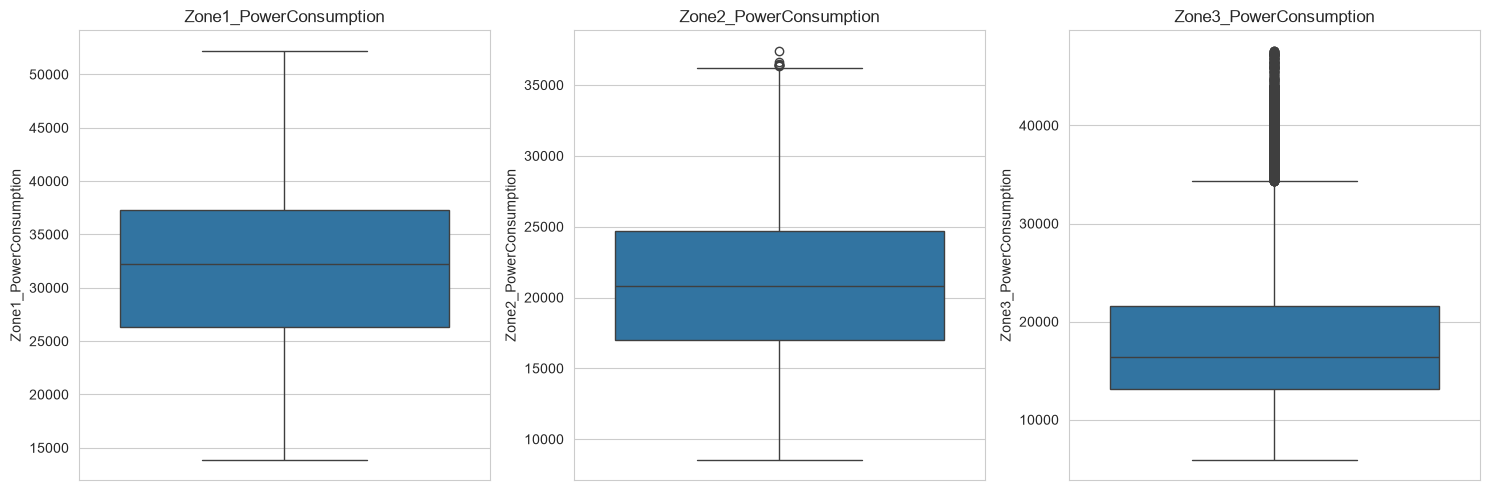

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
zones = ["Zone1_PowerConsumption", "Zone2_PowerConsumption", "Zone3_PowerConsumption"]
for ax, col in zip(axes, zones):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Kết luận:**
- **Zone 1**: không có outlier, phân bố cân đối, khoảng IQR rộng và đều.
- **Zone 2**: xuất hiện một vài outlier phía trên (~36.000+ KW).
- **Zone 3**: **nhiều outlier nhất**, đuôi trên kéo dài đến ~47.600 KW — xác nhận lại mức biến động mạnh vào mùa hè đã thấy ở bảng thống kê theo tháng.

## 6. Phân tích chuỗi thời gian

### 6.1. Xu hướng tổng theo thời gian

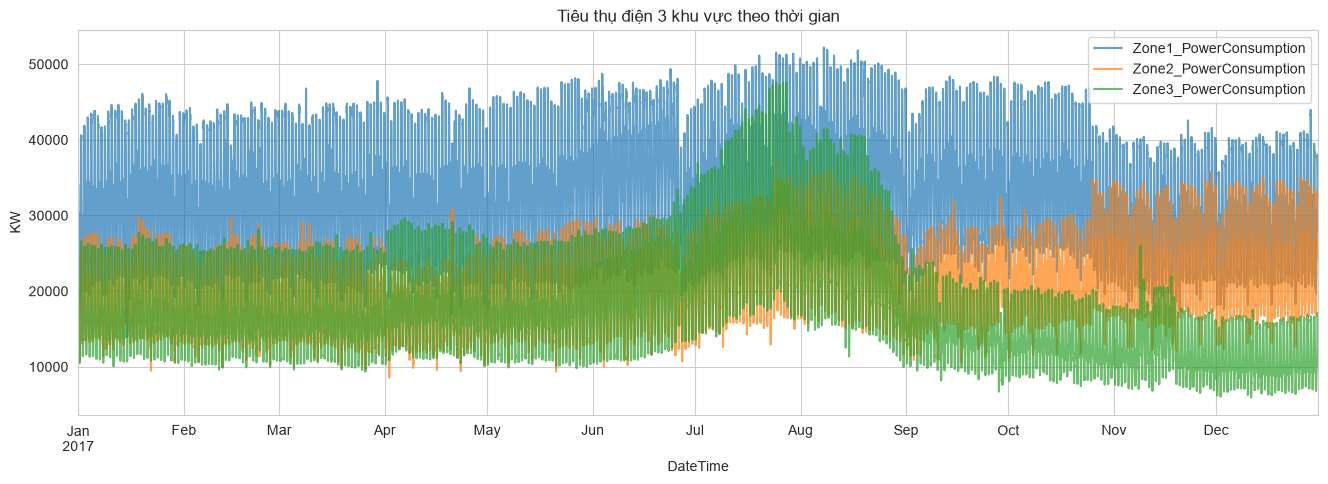

In [20]:
df[zones].plot(figsize=(16, 5), alpha=0.7)
plt.title("Tiêu thụ điện 3 khu vực theo thời gian")
plt.ylabel("KW")
plt.show()


**Kết luận:** Zone 1 luôn duy trì mức nền cao nhất quanh năm. Zone 2 và Zone 3 tăng mạnh trong giai đoạn **tháng 7-8**, thậm chí **hội tụ gần bằng Zone 1**, sau đó tách rời rõ rệt trở lại vào các tháng còn lại — cho thấy mùa hè làm thay đổi đáng kể cấu trúc tiêu thụ điện giữa các khu vực.

### 6.2. Trung bình theo giờ trong ngày (chu kỳ ngày)

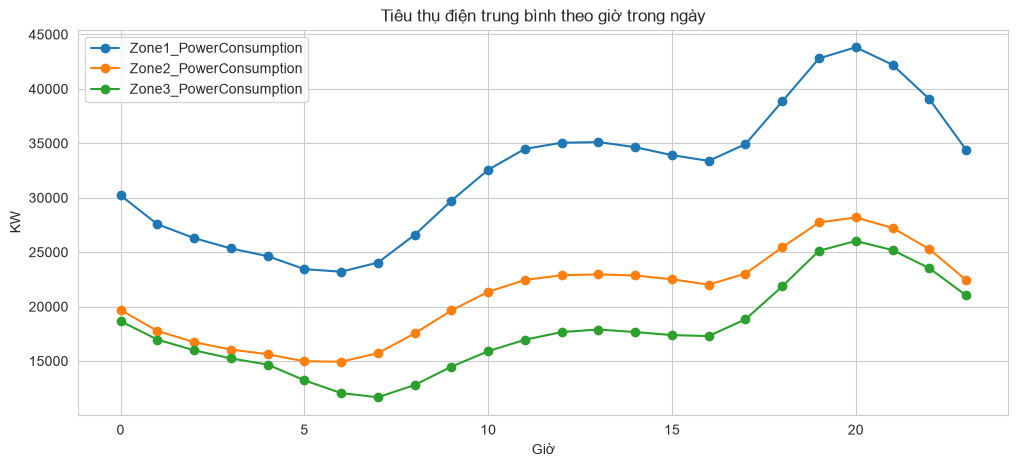

In [21]:
hourly_stats.plot(marker="o")
plt.title("Tiêu thụ điện trung bình theo giờ trong ngày")
plt.xlabel("Giờ")
plt.ylabel("KW")
plt.show()


**Kết luận:** Biểu đồ xác nhận rõ mẫu hình "hai pha" trong ngày: thấp điểm 5-7h sáng, tăng dần đến trưa, hơi chững đầu giờ chiều, rồi đạt **đỉnh cao nhất vào 19-20h**. Mẫu hình này lặp lại nhất quán ở cả 3 khu vực, dù biên độ dao động khác nhau (Zone 1 dao động ~20.000 KW, Zone 3 dao động mạnh nhất theo tỷ lệ %).

### 6.3. Trung bình theo tháng (chu kỳ mùa vụ)

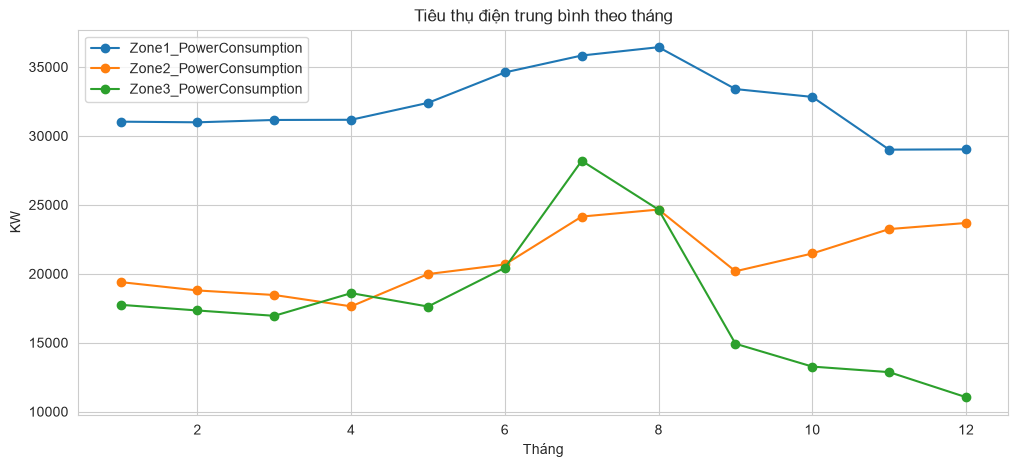

In [22]:
monthly_mean = df.groupby("month")[zones].mean()
monthly_mean.plot(marker="o")
plt.title("Tiêu thụ điện trung bình theo tháng")
plt.xlabel("Tháng")
plt.ylabel("KW")
plt.show()


**Kết luận:** Zone 1, Zone 2 có đường cong tiêu thụ theo tháng khá mượt (tăng dần giữa năm, giảm dần cuối năm). Riêng **Zone 3** có đỉnh "nhọn" bất thường vào tháng 7 rồi rơi mạnh — khác hẳn dạng đường mượt của 2 khu còn lại, gợi ý Zone 3 gắn với hoạt động phụ thuộc nhiệt độ cực đoan (có thể khu vực có tải làm mát/tưới tiêu tập trung mùa hè).

### 6.4. So sánh ngày thường và cuối tuần

In [23]:
df.groupby("is_weekend")[zones].mean()


,Zone1_PowerConsumption,Zone2_PowerConsumption,Zone3_PowerConsumption
is_weekend,,,
False,32676.336024,21546.446084,17776.365656
True,31516.556913,19782.666579,17983.007625


**Kết luận:**
- **Zone 1, Zone 2**: ngày thường tiêu thụ **cao hơn** cuối tuần (chênh lệch ~1.100–1.760 KW) → phù hợp với hoạt động thương mại/công nghiệp/hành chính.
- **Zone 3**: ngược lại, cuối tuần tiêu thụ **nhỉnh hơn** một chút → thiên về đặc điểm sinh hoạt dân cư.

### 6.5. Resample theo ngày để nhìn tổng quan xu hướng

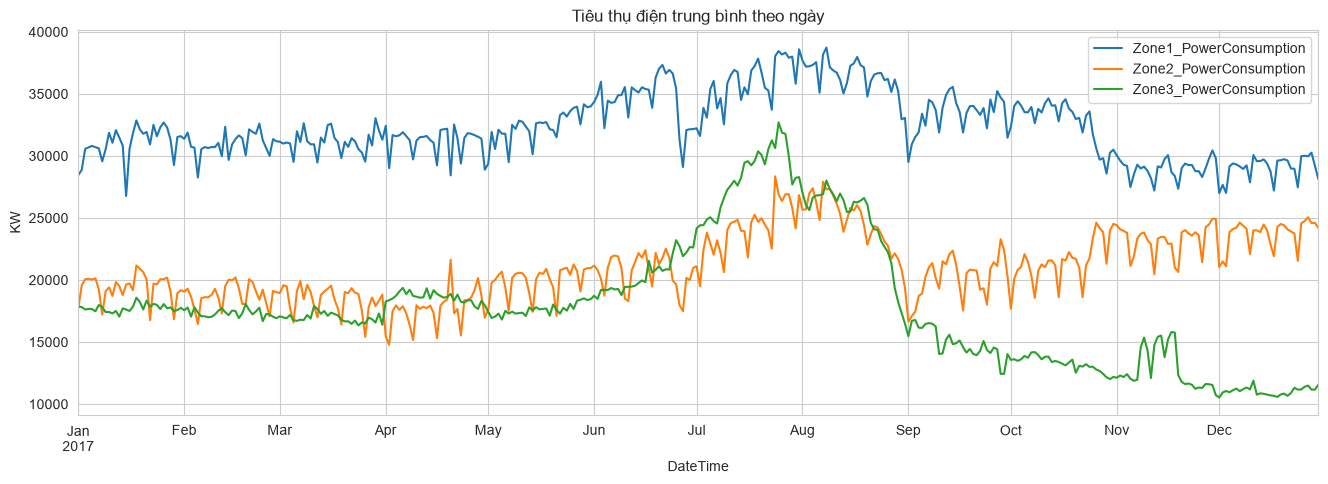

In [24]:
daily = df[zones].resample("D").mean()
daily.plot(figsize=(16, 5))
plt.title("Tiêu thụ điện trung bình theo ngày")
plt.ylabel("KW")
plt.show()


**Kết luận:** Chuỗi trung bình theo ngày cho thấy rõ chu kỳ mùa: tiêu thụ điện **tăng dần từ tháng 4, đạt đỉnh vào tháng 7-8, rồi giảm mạnh đầu tháng 9** ở cả 3 khu vực — khớp với chu kỳ nhiệt độ theo mùa của khí hậu Địa Trung Hải tại Tetouan.

## 7. Phân tích tương quan (Correlation Analysis)

### 7.1. Ma trận tương quan

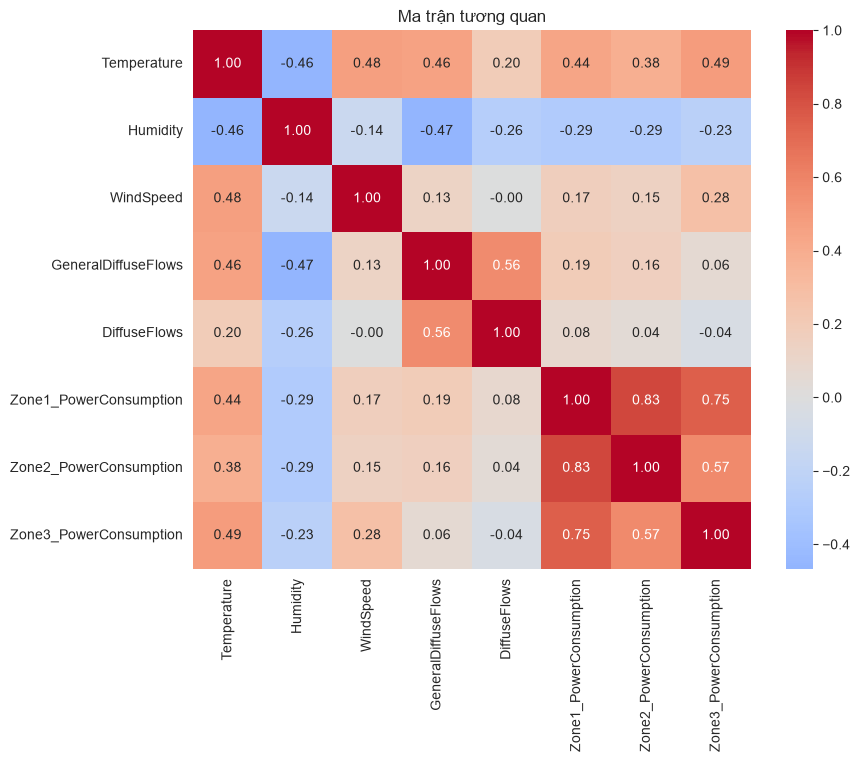

In [25]:
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Ma trận tương quan")
plt.show()


**Kết luận:**
- **Temperature** tương quan dương với cả 3 khu vực (0.38–0.49), mạnh nhất với **Zone 3** (0.49).
- **Humidity** tương quan âm với mọi khu vực (-0.23 đến -0.29) — độ ẩm cao thường đi kèm tiêu thụ điện thấp hơn.
- **GeneralDiffuseFlows & DiffuseFlows** tương quan rất mạnh với nhau (0.56, cùng đo bức xạ) nhưng tương quan yếu với tiêu thụ điện (≤ 0.19).
- **Zone1 ↔ Zone2** tương quan rất cao (0.83) — hai khu vực có hành vi tiêu thụ gần giống nhau; **Zone2 ↔ Zone3** yếu nhất (0.57) — hành vi khác biệt rõ nhất.

### 7.2. Scatter plot: Nhiệt độ vs Tiêu thụ điện

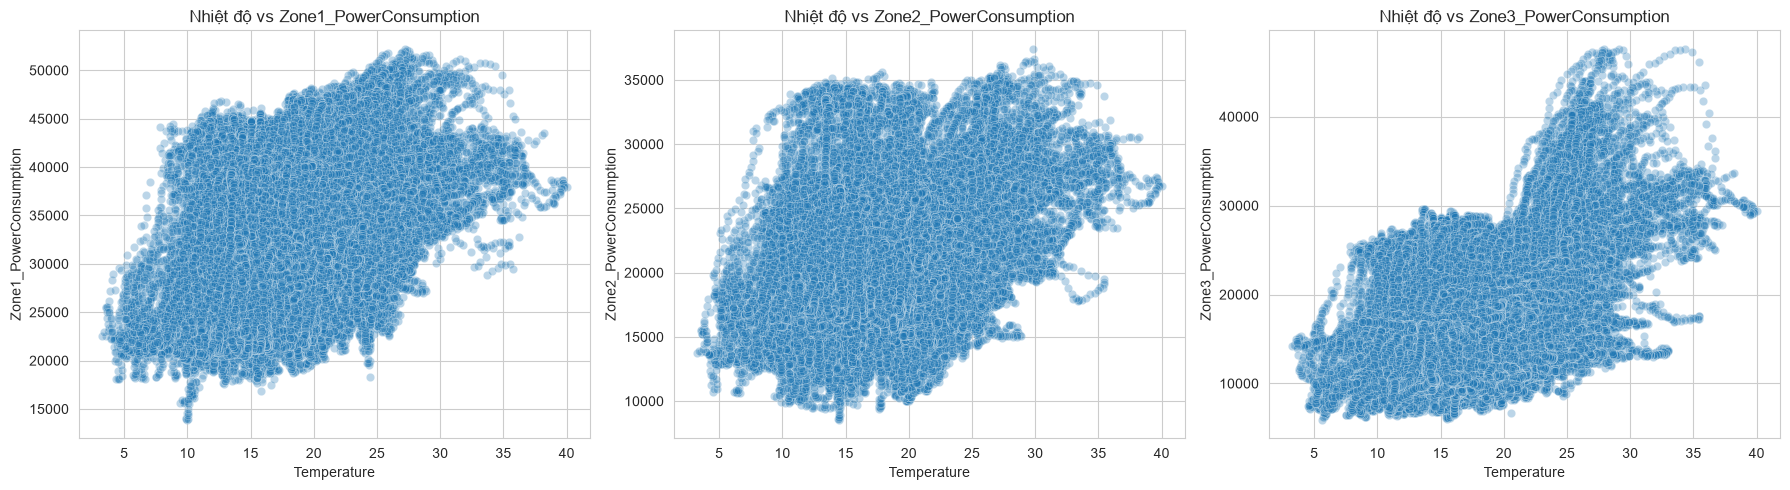

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, zone in zip(axes, zones):
    sns.scatterplot(x="Temperature", y=zone, data=df, alpha=0.3, ax=ax)
    ax.set_title(f"Nhiệt độ vs {zone}")
plt.tight_layout()
plt.show()


**Kết luận:** Cả 3 khu vực đều có xu hướng tiêu thụ tăng theo nhiệt độ nhưng **không tuyến tính hoàn toàn** — dạng "quạt mở" (phương sai tăng theo nhiệt độ). Nhiệt độ cao (>30°C) không đảm bảo tiêu thụ cao nếu rơi vào ban đêm → nhiệt độ chỉ là một yếu tố ảnh hưởng, cần kết hợp thêm biến giờ trong ngày để giải thích đầy đủ hơn.

### 7.3. Pairplot tổng quan (lấy mẫu để giảm tải)

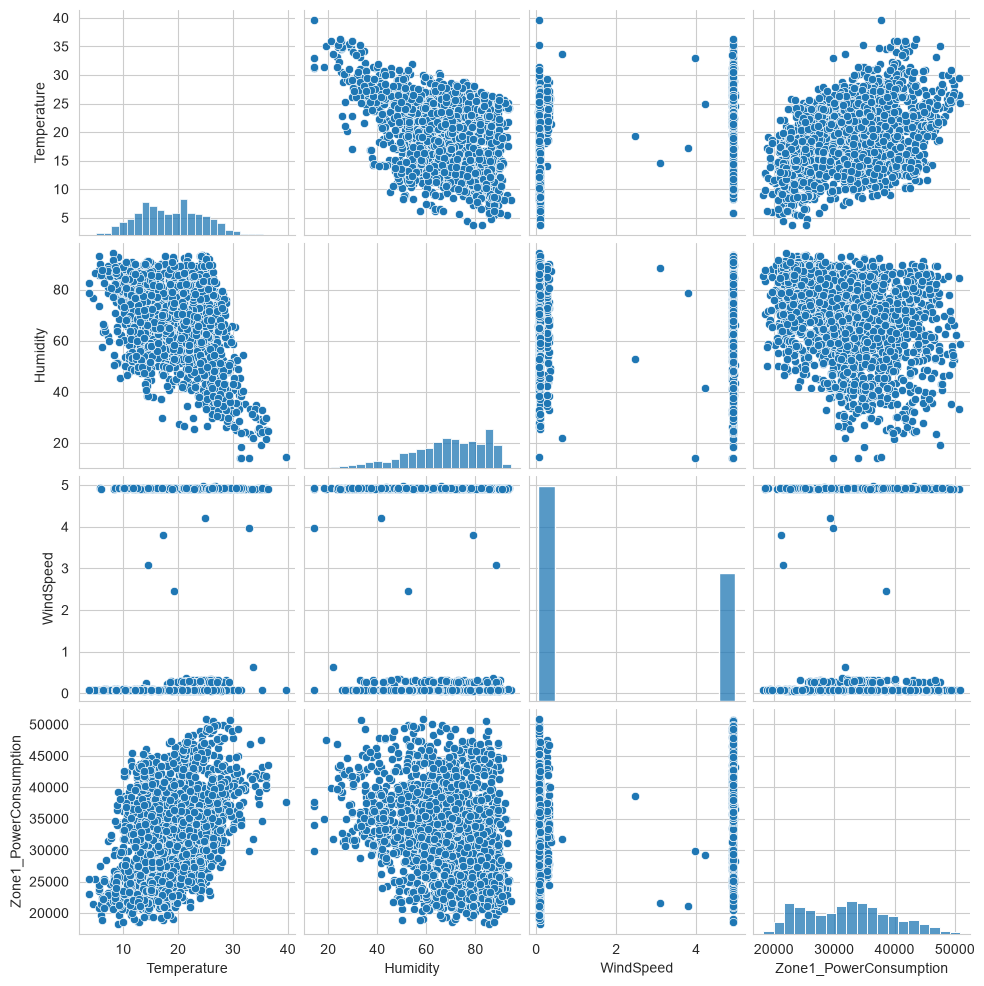

In [27]:
sample = df.sample(2000, random_state=42)
sns.pairplot(sample[["Temperature", "Humidity", "WindSpeed", "Zone1_PowerConsumption"]])
plt.show()


**Kết luận:** Pairplot xác nhận quan hệ **Temperature–Zone1** rõ nét nhất trong các cặp biến khí hậu–tiêu thụ điện; **Humidity–Zone1** có xu hướng nghịch biến; **WindSpeed** phân bố thành 2 cụm rõ rệt (gần 0 và gần 5) do đặc thù cách đo, không có quan hệ tuyến tính rõ với tiêu thụ điện.

## 8. So sánh giữa 3 khu vực (Zone 1, 2, 3)

In [28]:
df[zones].describe().T

,count,mean,std,min,25%,50%,75%,max
Zone1_PowerConsumption,52416.0,32344.970564,7130.562564,13895.696200,26310.668692,32265.920340,37309.018185,52204.39512
Zone2_PowerConsumption,52416.0,21042.509082,5201.465892,8560.081466,16980.766032,20823.168405,24713.717520,37408.86076
Zone3_PowerConsumption,52416.0,17835.406218,6622.165099,5935.174070,13129.326630,16415.117470,21624.100420,47598.32636


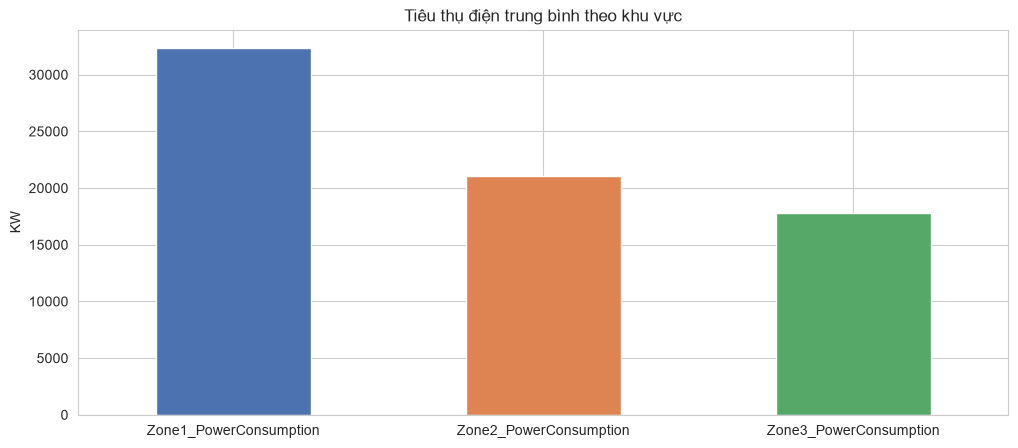

In [29]:
avg_zone = df[zones].mean()
avg_zone.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Tiêu thụ điện trung bình theo khu vực")
plt.ylabel("KW")
plt.xticks(rotation=0)
plt.show()


In [30]:
df[zones].corr()

,Zone1_PowerConsumption,Zone2_PowerConsumption,Zone3_PowerConsumption
Zone1_PowerConsumption,1.000000,0.834519,0.750733
Zone2_PowerConsumption,0.834519,1.000000,0.570932
Zone3_PowerConsumption,0.750733,0.570932,1.000000


**Kết luận:**
- **Zone 1 lớn nhất** (mean ≈ 32.345 KW) — gần gấp đôi Zone 3 (≈ 17.835 KW).
- Xét theo hệ số biến thiên (CV = std/mean): **Zone 1 ổn định nhất** (CV ≈ 22%), **Zone 3 biến động mạnh nhất** (CV ≈ 37%).
- Zone 1 và Zone 2 tiêu thụ "song hành" khá chặt (corr 0.83) — gợi ý đây là 2 khu vực có đặc điểm sử dụng điện tương tự (thương mại/dân cư ổn định); trong khi Zone 3 mang tính mùa vụ đặc thù hơn, phù hợp để ưu tiên phân tích sâu (dự báo/phân cụm) ở các bước tiếp theo.

## 9. Tổng hợp kết luận

- **Chất lượng dữ liệu**: dataset gần như không có giá trị thiếu / đã xử lý xong các giá trị thiếu, không có bất thường lớn.
=> Tiêu thụ điện tại Tetouan chịu chi phối rõ rệt bởi chu kỳ trong ngày (đỉnh tối 19-20h) và chu kỳ mùa (đỉnh hè tháng 7-8, do nhiệt độ tăng); nhiệt độ và độ ẩm là hai yếu tố khí hậu ảnh hưởng rõ nhất, còn bức xạ khuếch tán ảnh hưởng yếu. Zone 3 là khu vực đáng chú ý nhất để phân tích sâu hơn (dự báo/phân cụm) do có mức biến động và độ nhạy mùa vụ cao nhất trong 3 khu vực

